使用`Diff3DElasticity.py`得到的数据

`grad_diffdata.csv`是采用Differentiable方法得到

`grad_finite.csv`是采用finite difference方法得到

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator
from matplotlib import rcParams

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [2]:
grad_diffdata = np.loadtxt('3d_grad_diffdata.csv', delimiter=',')
grad_finite = np.loadtxt('3d_grad_finite.csv', delimiter=',')

error = np.abs(grad_diffdata - grad_finite)
# print('error:', error)
nmse = np.sum(error**2, axis=1) / np.sum(grad_diffdata**2 + grad_finite**2, axis=1)
# print('nmse:', nmse)

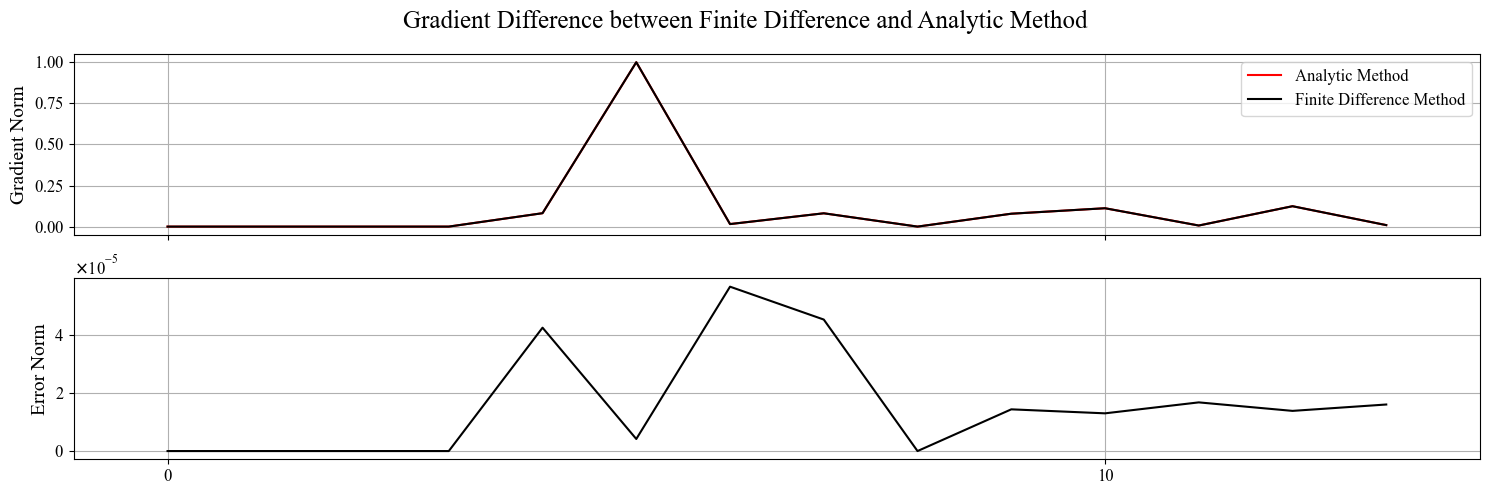

In [3]:
fig = plt.figure(figsize=(15, 5), dpi=100)
gs = GridSpec(2, 1, figure=fig)

fig.suptitle('Gradient Difference between Finite Difference and Analytic Method', fontsize=18)

ax_compare = fig.add_subplot(gs[0])
ax_compare.plot(np.linalg.norm(grad_diffdata, axis=1), label='Analytic Method', c='r')
ax_compare.plot(np.linalg.norm(grad_finite, axis=1), label='Finite Difference Method', c='k')
ax_compare.set_ylabel('Gradient Norm', fontsize=14)
ax_compare.legend(fontsize=12, loc='upper right')

ax_error = fig.add_subplot(gs[1])
ax_error.plot(np.linalg.norm(error, axis=1), c='k')
ax_error.set_ylabel('Error Norm', fontsize=14)

# ax_nmse = fig.add_subplot(gs[2])
# ax_nmse.plot(nmse, c='k')
# ax_nmse.set_ylabel('NMSE', fontsize=14)

axs = [ax_compare, ax_error]
for ax in axs:
    ax.set_xlim([-1, len(error)])
    ax.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.offsetText.set_fontsize(12)
    ax.yaxis.get_offset_text().set_fontsize(12)
    ax.grid('True', zorder=-1)
    ax.label_outer()

plt.tight_layout()
plt.show()

不用NSME来衡量误差，因为计算梯度对数值误差比较敏感，当梯度很小的时候，相对误差可能较大。但是梯度很小的部分，对模型的影响也小。

In [3]:
diffdata = np.loadtxt('../../grad_diffdata.csv', delimiter=',')
grad_finite = np.loadtxt('../../grad_finite.csv', delimiter=',')

error = np.abs(diffdata - grad_finite)
rel_error = error / np.abs(grad_finite)